# ASOS 2013–2022 AI-Ready 데이터 전처리 실습

**목표**: 기상청 ASOS 시간별 관측 자료(서울, STN=108)를 머신러닝/딥러닝에 바로 투입할 수 있는 형태로 정제한다.

**실습 순서**
1. 데이터 로드 & 개요
2. Sentinel 값(-9) 처리 → 진짜 NaN으로 변환
3. 이상값(outlier) 탐지 & 제거
4. 시간 gap 탐지 & 보간(Gap Filling)
5. 강수(-9) 특수 처리: 0 vs 결측 구분
6. 피처 선택 & 불필요 컬럼 제거
7. 표준화(Standardization) / 정규화(Normalization)
8. AI-Ready 저장 및 최종 검증

## 0. 라이브러리 & 설정

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
%cd /content/drive/MyDrive/Colab Notebooks/weather-climate-ai-tutorials

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import warnings
import matplotlib.font_manager as fm
warnings.filterwarnings('ignore')

# --- 한글 폰트 설정 (NanumGothic 직접 지정) ---
# Colab에 나눔 폰트 설치 및 캐시 갱신
!sudo apt-get install -y fonts-nanum
!fc-cache -fv
!rm -rf ~/.cache/matplotlib

NANUM_PATH = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(NANUM_PATH)
prop = fm.FontProperties(fname=NANUM_PATH)
font_name = prop.get_name()

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
print(f"한글 폰트 설정 완료: {font_name}")

print(f"xarray  : {xr.__version__}")
print(f"numpy   : {np.__version__}")
print(f"pandas  : {pd.__version__}")

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR = 'asos_data'
OUTPUT_DIR = 'asos_aiready'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 변수명 한글 설명
COL_DESC = {
    'TA':     '기온 [°C]',
    'TD':     '이슬점온도 [°C]',
    'HM':     '상대습도 [%]',
    'WD':     '풍향 [°]',
    'WS':     '풍속 [m/s]',
    'GST_WD': '순간최대풍향 [°]',
    'GST_WS': '순간최대풍속 [m/s]',
    'PA':     '현지기압 [hPa]',
    'PS':     '해면기압 [hPa]',
    'PV':     '수증기압 [hPa]',
    'RN':     '강수량 [mm/hr]',
    'RN_DAY': '일강수량 [mm]',
    'RN_INT': '강수강도 [mm/hr]',
    'SD_HR3': '3시간적설 [cm]',
    'SD_DAY': '일적설 [cm]',
    'SD_TOT': '적설 [cm]',
    'CA_TOT': '전운량 [0-10]',
    'CA_MID': '중하층운량 [0-10]',
    'CH_MIN': '최저운고 [100ft]',
    'VS':     '시정 [m]',
    'SS':     '일조 [초, 0-3600]',
    'SI':     '일사 [MJ/m²]',
    'ST_GD':  '지면상태 코드',
    'TS':     '지면온도 [°C]',
    'TE_005': '지중온도 5cm [°C]',
    'TE_01':  '지중온도 10cm [°C]',
    'TE_02':  '지중온도 20cm [°C]',
    'TE_03':  '지중온도 30cm [°C]',
    'ST_SEA': '해면수온 [°C]',
    'WH':     '파고 [m]',
    'BF':     '보퍼트 풍력계급',
}

def desc(col):
    """변수 코드 → 한글 설명"""
    return COL_DESC.get(col, col)

def print_col_info(cols):
    """컬럼 목록의 코드·설명 출력"""
    for c in cols:
        print(f'  {c:12s} : {COL_DESC.get(c, "-")}')

# ASOS 주요 수치 컬럼 정의 (문자 컬럼 제외)
NUMERIC_COLS = [
    'WD','WS','GST_WD','GST_WS',
    'PA','PS',
    'TA','TD','HM','PV',
    'RN','RN_DAY','RN_INT',
    'SD_HR3','SD_DAY','SD_TOT',
    'CA_TOT','CA_MID','CH_MIN',
    'VS','SS','SI',
    'ST_GD','TS',
    'TE_005','TE_01','TE_02','TE_03',
    'ST_SEA','WH','BF',
]

# AI 모델에 주로 쓰이는 핵심 피처
CORE_FEATURES = ['TA','TD','HM','WD','WS','PA','PS','RN','SS','VS']

print('설정 완료')
print()
print('=== 핵심 피처 변수 설명 ===')
print_col_info(CORE_FEATURES)

설정 완료

=== 핵심 피처 변수 설명 ===
  TA           : 기온 [°C]
  TD           : 이슬점온도 [°C]
  HM           : 상대습도 [%]
  WD           : 풍향 [°]
  WS           : 풍속 [m/s]
  PA           : 현지기압 [hPa]
  PS           : 해면기압 [hPa]
  RN           : 강수량 [mm/hr]
  SS           : 일조 [초, 0-3600]
  VS           : 시정 [m]


## 1. 데이터 로드 & 개요

In [2]:
dfs = []
for yr in range(2013, 2023):
    path = os.path.join(DATA_DIR, f'asos_{yr}_merged.csv')
    d = pd.read_csv(path)
    dfs.append(d)
    print(f'{yr}: {len(d):,} rows')

df_raw = pd.concat(dfs, ignore_index=True)
df_raw['TM'] = pd.to_datetime(df_raw['TM'], format='%Y%m%d%H%M')
df_raw = df_raw.sort_values('TM').reset_index(drop=True)

print(f'\n전체: {len(df_raw):,} rows, {len(df_raw.columns)} columns')
print(f'기간: {df_raw["TM"].min()} ~ {df_raw["TM"].max()}')
df_raw.head(3)

2013: 8,765 rows
2014: 8,764 rows
2015: 8,760 rows
2016: 8,784 rows
2017: 8,757 rows
2018: 8,760 rows
2019: 8,758 rows
2020: 8,784 rows
2021: 8,760 rows
2022: 8,760 rows

전체: 87,652 rows, 46 columns
기간: 2013-01-01 00:00:00 ~ 2022-12-31 23:00:00


,TM,STN,WD,WS,GST_WD,GST_WS,GST_TM,PA,PS,PT,...,TE_005,TE_01,TE_02,TE_03,ST_SEA,WH,BF,IR,IX,RN_JUN
0,2013-01-01 00:00:00,108,5,3.6,-9,-9.0,-9,1010.3,1021.5,7,...,-3.3,-2.9,-1.6,-0.5,0.3,-9,-9.0,-9,3,2
1,2013-01-01 01:00:00,108,5,4.0,-9,-9.0,-9,1010.0,1021.2,-9,...,-3.4,-2.9,-1.6,-0.5,0.3,-9,-9.0,-9,3,-9
2,2013-01-01 02:00:00,108,7,4.0,-9,-9.0,-9,1009.4,1020.6,-9,...,-3.4,-3.0,-1.6,-0.5,0.4,-9,-9.0,-9,3,-9


In [3]:
# 컬럼 타입 확인
print('=== 데이터 타입 ===')  
print(df_raw.dtypes)
print()
print('=== 기본 통계 (핵심 피처) ===')
df_raw[CORE_FEATURES].describe()

=== 데이터 타입 ===
TM        datetime64[us]
STN                int64
WD                 int64
WS               float64
GST_WD             int64
GST_WS           float64
GST_TM             int64
PA               float64
PS               float64
PT                 int64
PR               float64
TA               float64
TD               float64
HM               float64
PV               float64
RN               float64
RN_DAY           float64
RN_INT           float64
SD_HR3           float64
SD_DAY           float64
SD_TOT           float64
WC               float64
WP                 int64
WW                 int64
CA_TOT               str
CA_MID             int64
CH_MIN             int64
CT                 int64
CT_TOP               str
CT_MID             int64
CT_LOW             int64
VS                 int64
SS                 int64
SI               float64
ST_GD            float64
TS                 int64
TE_005           float64
TE_01            float64
TE_02            float64
TE_03     

,TA,TD,HM,WD,WS,PA,PS,RN,SS,VS
count,87652.000000,87652.000000,87652.000000,87652.000000,87652.000000,87652.000000,87652.000000,87652.000000,87652.00000,87652.000000
mean,13.306008,5.114052,60.728066,19.262139,2.327621,1005.910177,1016.192187,-7.968697,1403.92954,-1.872484
std,11.081829,12.281327,19.894579,11.015890,1.307869,15.939310,15.521819,3.292105,669.38948,6.565107
min,-99.000000,-31.100000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.000000,-9.00000,-9.000000
25%,4.200000,-4.500000,46.000000,7.000000,1.400000,999.700000,1009.500000,-9.000000,828.00000,-9.000000
50%,14.300000,5.900000,61.000000,25.000000,2.200000,1006.300000,1016.500000,-9.000000,1700.00000,0.000000
75%,22.800000,15.900000,77.000000,29.000000,3.100000,1012.400000,1023.000000,-9.000000,2000.00000,5.000000
max,39.400000,27.900000,100.000000,36.000000,10.600000,1028.300000,1039.600000,64.700000,5000.00000,9.000000


## 2. Sentinel 값(-9) 처리

**ASOS 결측 코드**: `-9` (일부 항목은 `-99`)

단, **온도류 컬럼은 sentinel 처리에서 제외**:
- `TA`, `TD`, `TS`, `TE_*` 등 온도 변수는 -9°C가 실제 관측값일 수 있음 (서울 겨울)
- 온도류의 이상값은 §3 물리적 범위 체크(`< -35°C` 등)로만 걸러냄

| 구분 | 컬럼 예시 | -9 처리 |
|------|-----------|---------|
| **일반 수치** | HM, WS, PA, PS, WD … | -9 → NaN (물리적으로 불가능) |
| **온도류** | TA, TD, TS, TE_* | -9 그대로 유지 → 물리범위로 판단 |
| **강수** | RN, RN_DAY, RN_INT | §5에서 별도 처리 (0 vs 결측 구분) |

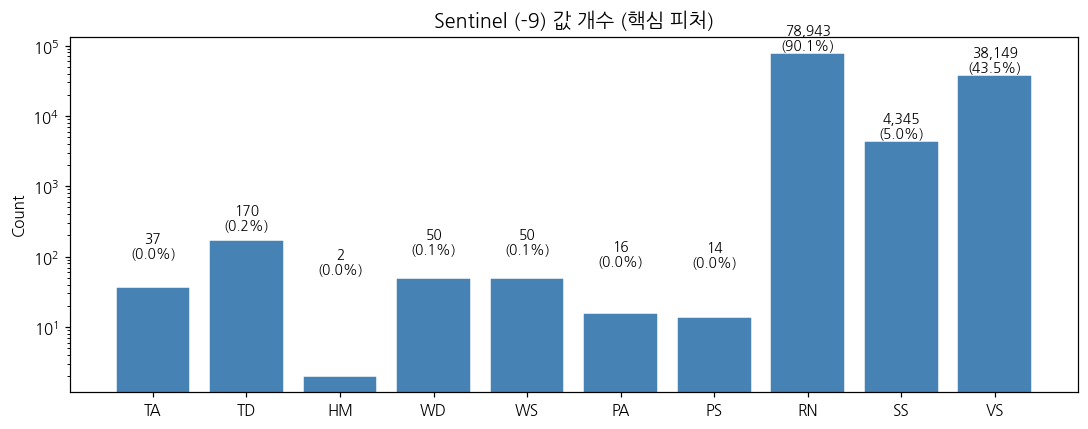


=== 전체 컬럼 sentinel(-9) 비율 ===
  WD          :     50 / 87,652 (0.1%)
  WS          :     50 / 87,652 (0.1%)
  GST_WD      : 83,074 / 87,652 (94.8%)
  GST_WS      : 83,074 / 87,652 (94.8%)
  PA          :     16 / 87,652 (0.0%)
  PS          :     14 / 87,652 (0.0%)
  TA          :     37 / 87,652 (0.0%)
  TD          :    170 / 87,652 (0.2%)
  HM          :      2 / 87,652 (0.0%)
  RN          : 78,943 / 87,652 (90.1%)
  RN_DAY      : 63,458 / 87,652 (72.4%)
  RN_INT      : 63,466 / 87,652 (72.4%)
  SD_HR3      : 87,652 / 87,652 (100.0%)
  SD_DAY      : 87,401 / 87,652 (99.7%)
  SD_TOT      : 86,579 / 87,652 (98.8%)
  CA_MID      : 10,805 / 87,652 (12.3%)
  CH_MIN      :  7,141 / 87,652 (8.1%)
  VS          : 38,149 / 87,652 (43.5%)
  SS          :  4,345 / 87,652 (5.0%)
  SI          : 39,764 / 87,652 (45.4%)
  ST_GD       : 39,953 / 87,652 (45.6%)
  TS          : 82,536 / 87,652 (94.2%)
  TE_005      :     91 / 87,652 (0.1%)
  TE_01       :      1 / 87,652 (0.0%)
  WH          : 87,

In [4]:
import matplotlib
matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

df = df_raw.copy()

# -9 sentinel 분포 시각화 (핵심 피처)
sentinel_counts = {}
for col in CORE_FEATURES:
    if col in df.columns:
        cnt = (df[col] == -9).sum()
        sentinel_counts[col] = cnt

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(sentinel_counts.keys(), sentinel_counts.values(), color='steelblue', edgecolor='white')
for bar, val in zip(bars, sentinel_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=9)
ax.set_title('Sentinel (-9) 값 개수 (핵심 피처)', fontsize=13)
ax.set_ylabel('Count')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

print('\n=== 전체 컬럼 sentinel(-9) 비율 ===')
for col in NUMERIC_COLS:
    if col in df.columns:
        cnt = (df[col] == -9).sum()
        if cnt > 0:
            print(f'  {col:12s}: {cnt:6,} / {len(df):,} ({cnt/len(df)*100:.1f}%)')

In [5]:
# 온도류: -9가 실제 관측값(-9°C)일 수 있으므로 sentinel 처리 제외
# → §3 물리적 범위 체크(< -35°C)로만 이상값 판단
TEMP_COLS = ['TA', 'TD', 'TS', 'TE_005', 'TE_01', 'TE_02', 'TE_03']

# sentinel 처리 대상: 강수·온도류 제외
SENTINEL_COLS = [
    c for c in NUMERIC_COLS
    if c in df.columns
    and c not in ['RN', 'RN_DAY', 'RN_INT']
    and c not in TEMP_COLS
]

# -9 → NaN (온도류 제외)
for col in SENTINEL_COLS:
    mask = df[col] == -9
    if mask.any():
        df.loc[mask, col] = np.nan

# -99 → NaN (온도류 포함, -99°C는 물리적으로 불가능)
for col in [c for c in NUMERIC_COLS if c in df.columns and c not in ['RN', 'RN_DAY', 'RN_INT']]:
    mask = df[col] == -99
    if mask.any():
        print(f'  {col}: -99 값 {mask.sum()}개 → NaN')
        df.loc[mask, col] = np.nan

# ★ sentinel 처리 직후 상태 저장 → cell-12 before/after 비교에 사용
df_after_sentinel = df.copy()

print('Sentinel 처리 완료')
print(f'  처리된 컬럼 ({len(SENTINEL_COLS)}개): sentinel -9 → NaN')
print(f'  제외된 컬럼: {[c for c in TEMP_COLS if c in df.columns]} (온도류, 물리범위로 처리)')
print(f'\nTA NaN: {df["TA"].isna().sum()}개  ← -9°C 보존됨')
print(f'HM NaN: {df["HM"].isna().sum()}개')

  TA: -99 값 3개 → NaN
  TE_01: -99 값 76개 → NaN
  TE_02: -99 값 72개 → NaN
  TE_03: -99 값 85개 → NaN
  ST_SEA: -99 값 157개 → NaN
Sentinel 처리 완료
  처리된 컬럼 (21개): sentinel -9 → NaN
  제외된 컬럼: ['TA', 'TD', 'TS', 'TE_005', 'TE_01', 'TE_02', 'TE_03'] (온도류, 물리범위로 처리)

TA NaN: 3개  ← -9°C 보존됨
HM NaN: 2개


## 3. 이상값(Outlier) 탐지 & 제거

**3가지 방법 비교**
1. **물리적 범위 체크** (도메인 지식 기반, 가장 신뢰성 높음)
2. **IQR 방법** (분포 기반, 계절성에 취약)
3. **Z-score** (정규분포 가정)

> ASOS처럼 계절 변동이 큰 데이터에는 **물리적 범위 체크**가 제일 적합

물리적 범위 초과 이상값이 있는 변수: ['SS']
  SS   [0, 3600] 초  → 총 8개 (0.0096%)  [하한 미만 0 | 상한 초과 8]


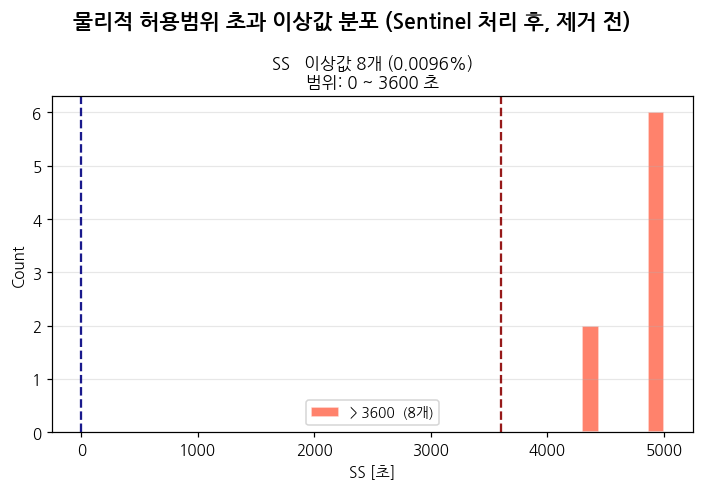

→ asos_outlier_histograms.png 저장 완료


In [6]:
# ── 물리적 허용범위 초과 이상값 히스토그램 (제거 전 분포 확인) ──────────────────
import matplotlib
matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

PHYSICAL_BOUNDS = {
    'TA':   (-35, 42),      # 기온 [°C]
    'TD':   (-40, 35),      # 이슬점온도 [°C]
    'HM':   (0, 100),       # 상대습도 [%]
    'WS':   (0, 80),        # 풍속 [m/s]
    'WD':   (0, 360),       # 풍향 [°]
    'PA':   (850, 1060),    # 현지기압 [hPa]
    'PS':   (950, 1060),    # 해면기압 [hPa]
    'SS':   (0, 3600),      # 일조 [초]
    'VS':   (0, 99999),     # 시정 [m]
    'PV':   (0, 80),        # 수증기압 [hPa]
}
UNIT_LABELS = {
    'TA':'°C','TD':'°C','HM':'%','WS':'m/s','WD':'°',
    'PA':'hPa','PS':'hPa','SS':'초','VS':'m','PV':'hPa',
}

# 이상값 수집
outlier_data = {}
for col, (lo, hi) in PHYSICAL_BOUNDS.items():
    if col not in df.columns:
        continue
    mask = (df[col] < lo) | (df[col] > hi)
    vals = df.loc[mask, col].dropna()
    if len(vals) > 0:
        outlier_data[col] = dict(values=vals, lo=lo, hi=hi,
                                 n=len(vals), total=df[col].notna().sum())

print(f'물리적 범위 초과 이상값이 있는 변수: {list(outlier_data.keys())}')
for col, info in outlier_data.items():
    below = (info['values'] < info['lo']).sum()
    above = (info['values'] > info['hi']).sum()
    pct   = info['n'] / info['total'] * 100
    print(f"  {col:4s} [{info['lo']}, {info['hi']}] {UNIT_LABELS.get(col,'')}  "
          f"→ 총 {info['n']:,}개 ({pct:.4f}%)  "
          f"[하한 미만 {below:,} | 상한 초과 {above:,}]")

if not outlier_data:
    print("이상값 없음 — 히스토그램 생략")
else:
    n_plots = len(outlier_data)
    ncols   = min(3, n_plots)
    nrows   = (n_plots + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(6.5*ncols, 4.5*nrows), squeeze=False)
    fig.suptitle('물리적 허용범위 초과 이상값 분포 (Sentinel 처리 후, 제거 전)',
                 fontsize=14, fontweight='bold')

    for idx, (col, info) in enumerate(outlier_data.items()):
        ax   = axes[idx // ncols][idx % ncols]
        vals = info['values']
        lo, hi = info['lo'], info['hi']
        unit = UNIT_LABELS.get(col, '')

        below = vals[vals < lo]
        above = vals[vals > hi]
        bins  = min(60, max(10, len(vals) // 3))

        if len(below) > 0:
            ax.hist(below.values, bins=max(5, bins//2), color='steelblue',
                    alpha=0.8, edgecolor='white', label=f'< {lo}  ({len(below):,}개)')
        if len(above) > 0:
            ax.hist(above.values, bins=max(5, bins//2), color='tomato',
                    alpha=0.8, edgecolor='white', label=f'> {hi}  ({len(above):,}개)')

        ax.axvline(lo, color='navy',    ls='--', lw=1.5, alpha=0.9)
        ax.axvline(hi, color='darkred', ls='--', lw=1.5, alpha=0.9)

        pct = info['n'] / info['total'] * 100
        ax.set_title(f'{col}   이상값 {info["n"]:,}개 ({pct:.4f}%)\n범위: {lo} ~ {hi} {unit}',
                     fontsize=11)
        ax.set_xlabel(f'{col} [{unit}]')
        ax.set_ylabel('Count')
        ax.legend(fontsize=9)
        ax.grid(axis='y', alpha=0.3)

    for idx in range(n_plots, nrows * ncols):
        axes[idx // ncols][idx % ncols].set_visible(False)

    plt.tight_layout()
    plt.savefig('asos_outlier_histograms.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('→ asos_outlier_histograms.png 저장 완료')

In [7]:
# 물리적 허용 범위 정의 (한국 기후 + 센서 스펙 기반)
PHYSICAL_BOUNDS = {
    'TA':   (-35, 42),      # 기온 [°C]
    'TD':   (-40, 35),      # 이슬점온도 [°C]
    'HM':   (0, 100),       # 상대습도 [%]
    'WS':   (0, 80),        # 풍속 [m/s]
    'WD':   (0, 360),       # 풍향 [°]
    'PA':   (850, 1060),    # 현지기압 [hPa]
    'PS':   (950, 1060),    # 해면기압 [hPa]
    'SS':   (0, 3600),      # 일조 [초]
    'VS':   (0, 99999),     # 시정 [m]
    'PV':   (0, 80),        # 수증기압 [hPa]
}

outlier_report = {}

for col, (lo, hi) in PHYSICAL_BOUNDS.items():
    if col not in df.columns:
        continue
    mask_out = (df[col] < lo) | (df[col] > hi)
    n = mask_out.sum()
    outlier_report[col] = n
    if n > 0:
        print(f'  {col}: {n}개 이상값 → NaN [허용범위: {lo}~{hi}]')
        print('    값:', df.loc[mask_out, ["TM", col]].to_string(index=False))
        df.loc[mask_out, col] = np.nan

print('\n물리적 범위 기반 이상값 처리 완료')

  SS: 8개 이상값 → NaN [허용범위: 0~3600]
    값:                  TM     SS
2020-10-28 12:00:00 4430.0
2020-10-28 13:00:00 4300.0
2020-10-28 14:00:00 5000.0
2020-10-28 15:00:00 5000.0
2020-10-28 16:00:00 5000.0
2020-10-28 17:00:00 5000.0
2020-10-28 18:00:00 5000.0
2020-10-28 19:00:00 5000.0

물리적 범위 기반 이상값 처리 완료


단계 1 (완전 raw)        : 87,652개
단계 2 (sentinel 처리 후): 87,649개  (-99 제거: 3개, -9°C 보존)
단계 3 (물리범위 제거 후): 87,649개  (범위 초과 제거: 0개)


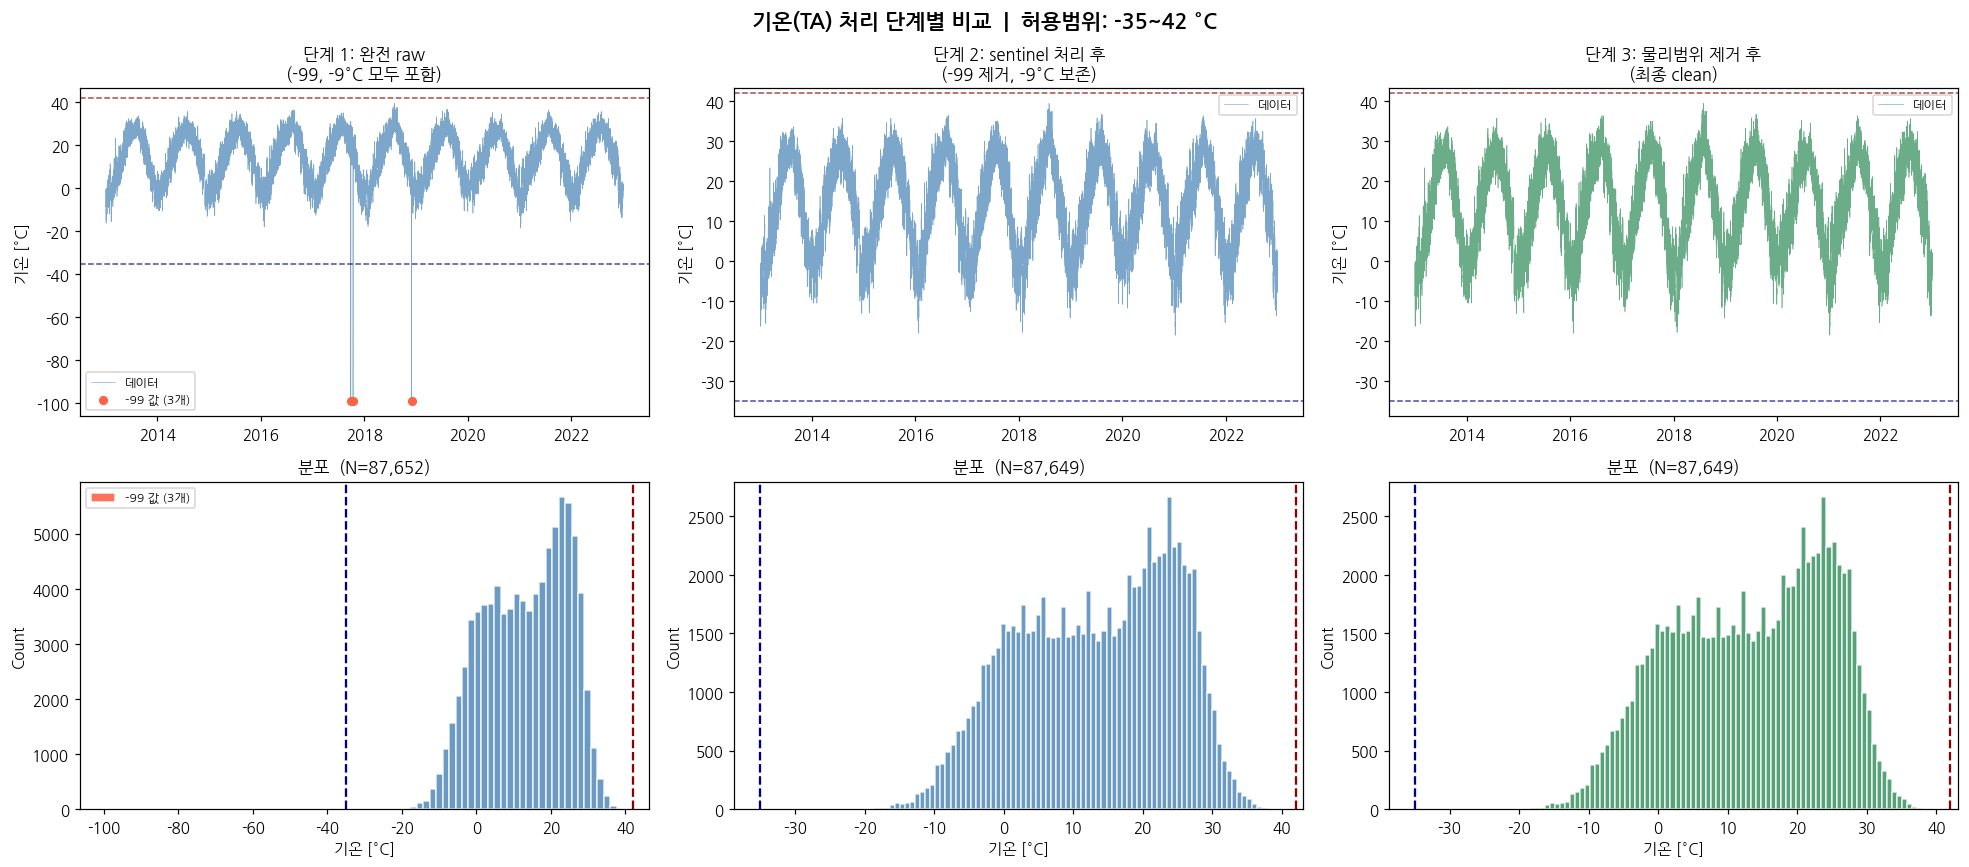

In [8]:
# TA 3단계 처리 전/후 비교 시각화
# 단계 1: 완전 raw (-9, -99 그대로)
# 단계 2: sentinel 처리 후 (-99→NaN, -9°C는 보존)
# 단계 3: 물리적 범위 이상값까지 제거
ta_lo, ta_hi = PHYSICAL_BOUNDS['TA']

ta_raw    = df_raw['TA'].copy()                # 단계 1: 완전 원본
ta_senti  = df_after_sentinel['TA'].copy()     # 단계 2: sentinel 처리 후
ta_clean  = df['TA'].copy()                    # 단계 3: 물리범위 제거 후
time_index = df_raw['TM']

# -99 위치 (단계 1→2에서 제거되는 것)
mask_99 = ta_raw == -99
# 물리범위 이상값 위치 (단계 2→3에서 제거되는 것, -99 제외)
mask_phys = (ta_senti < ta_lo) | (ta_senti > ta_hi)

n1 = ta_raw.notna().sum()
n2 = ta_senti.notna().sum()
n3 = ta_clean.notna().sum()
print(f'단계 1 (완전 raw)        : {n1:,}개')
print(f'단계 2 (sentinel 처리 후): {n2:,}개  (-99 제거: {mask_99.sum()}개, -9°C 보존)')
print(f'단계 3 (물리범위 제거 후): {n3:,}개  (범위 초과 제거: {mask_phys.sum()}개)')

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle(f'기온(TA) 처리 단계별 비교  |  허용범위: {ta_lo}~{ta_hi} °C',
             fontsize=14, fontweight='bold')

STAGES = [
    (ta_raw,   '단계 1: 완전 raw\n(-99, -9°C 모두 포함)',   'steelblue',  mask_99,   'tomato',  f'-99 값 ({mask_99.sum()}개)'),
    (ta_senti, '단계 2: sentinel 처리 후\n(-99 제거, -9°C 보존)', 'steelblue', mask_phys, 'orange',  f'물리범위 초과 ({mask_phys.sum()}개)'),
    (ta_clean, '단계 3: 물리범위 제거 후\n(최종 clean)',      'seagreen',   None,      None,      None),
]

for i, (series, title, color, outlier_mask, out_color, out_label) in enumerate(STAGES):
    # ── 시계열 (상단) ──
    ax = axes[0, i]
    ax.plot(time_index, series, lw=0.4, color=color, alpha=0.7, label='데이터')
    if outlier_mask is not None and outlier_mask.sum() > 0:
        ax.scatter(time_index[outlier_mask], series[outlier_mask],
                   color=out_color, s=25, zorder=5, label=out_label)
    ax.axhline(ta_lo, color='navy',    ls='--', lw=1, alpha=0.7)
    ax.axhline(ta_hi, color='darkred', ls='--', lw=1, alpha=0.7)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('기온 [°C]')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    # ── 히스토그램 (하단) ──
    ax = axes[1, i]
    ax.hist(series.dropna(), bins=80, color=color, alpha=0.8, edgecolor='white')
    if outlier_mask is not None and outlier_mask.sum() > 0:
        ax.hist(series[outlier_mask].dropna(), bins=20,
                color=out_color, alpha=0.9, edgecolor='white', label=out_label)
        ax.legend(fontsize=8)
    ax.axvline(ta_lo, color='navy',    ls='--', lw=1.5)
    ax.axvline(ta_hi, color='darkred', ls='--', lw=1.5)
    ax.set_xlabel('기온 [°C]')
    ax.set_ylabel('Count')
    ax.set_title(f'분포  (N={series.notna().sum():,})', fontsize=11)

plt.tight_layout()
plt.savefig('asos_ta_outlier_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

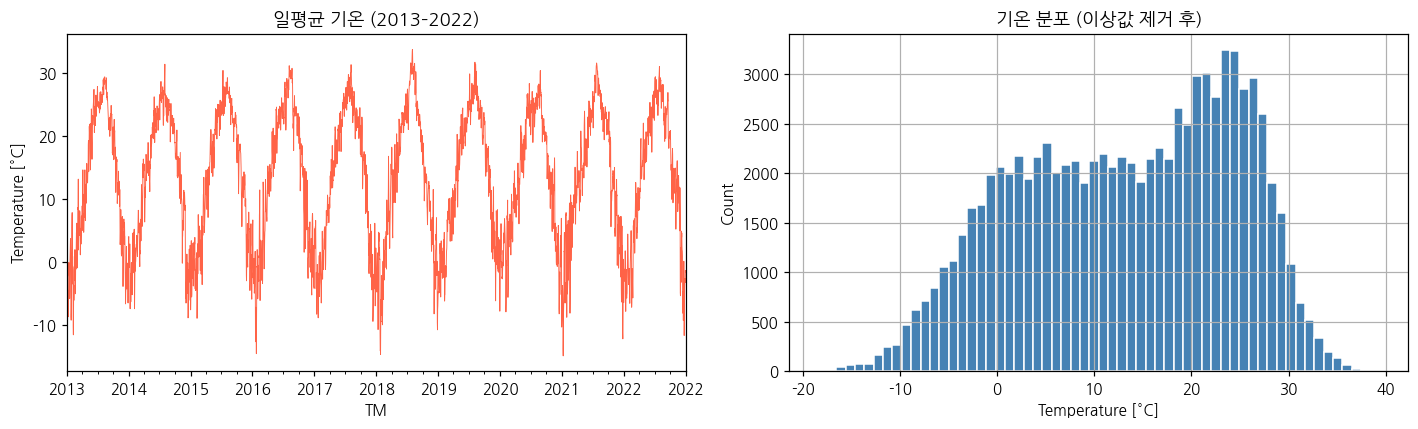

In [9]:
# TA 분포 시각화 (이상값 제거 전/후)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 연간 TA 시계열
ax = axes[0]
df.set_index('TM')['TA'].resample('D').mean().plot(ax=ax, lw=0.6, color='tomato')
ax.set_title('일평균 기온 (2013–2022)', fontsize=12)
ax.set_ylabel('Temperature [°C]')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 히스토그램
ax = axes[1]
df['TA'].hist(bins=60, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('기온 분포 (이상값 제거 후)', fontsize=12)
ax.set_xlabel('Temperature [°C]')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

## 4. 시간 Gap 탐지 & 보간 (Gap Filling)

시계열 AI 모델(LSTM, Transformer 등)은 **균일한 시간 간격**을 요구함  
→ 빠진 타임스텝을 만들고, 단기 gap은 선형/스플라인 보간, 장기 gap은 표시

In [10]:
# 완전한 시간 인덱스 생성 (1시간 간격)
full_index = pd.date_range(start=df['TM'].min(), end=df['TM'].max(), freq='h')
df_indexed = df.set_index('TM').reindex(full_index)

# gap 크기별 분류
nan_mask = df_indexed['TA'].isna()
gap_sizes = []
in_gap = False
gap_start = None

for t, is_nan in nan_mask.items():
    if is_nan and not in_gap:
        in_gap = True
        gap_start = t
        gap_count = 1
    elif is_nan and in_gap:
        gap_count += 1
    elif not is_nan and in_gap:
        gap_sizes.append({'start': gap_start, 'end': t, 'hours': gap_count})
        in_gap = False

gap_df = pd.DataFrame(gap_sizes)
print(f'완전한 타임스텝 수: {len(full_index):,}')
print(f'현재 row 수: {len(df):,}')
print(f'누락 타임스텝: {len(full_index) - len(df_indexed.dropna(how="all")):,}')
print()
print('=== 시간 gap 목록 (TA 기준) ===')
print(gap_df if len(gap_df) > 0 else '없음')

완전한 타임스텝 수: 87,648
현재 row 수: 87,652
누락 타임스텝: 5

=== 시간 gap 목록 (TA 기준) ===
                start                 end  hours
0 2017-09-26 17:00:00 2017-09-26 18:00:00      1
1 2017-10-12 15:00:00 2017-10-12 18:00:00      3
2 2017-11-03 19:00:00 2017-11-03 20:00:00      1
3 2018-11-29 18:00:00 2018-11-29 19:00:00      1
4 2019-12-12 21:00:00 2019-12-12 23:00:00      2


In [11]:
# Gap Filling 전략:
#   ≤6시간 gap  → 선형 보간 (linear)
#   7~24시간 gap → 계절 평균 보간 (같은 月·시각의 10년 평균)
#   >24시간 gap  → 플래그만 추가 (모델 학습 시 마스킹)

SHORT_GAP = 6   # 시간
LONG_GAP  = 24  # 시간

# 1단계: 단기 gap → 선형 보간
fill_cols = ['TA','TD','HM','WS','PA','PS','VS','SS']
fill_cols = [c for c in fill_cols if c in df_indexed.columns]

df_fill = df_indexed.copy()

for col in fill_cols:
    df_fill[col] = df_fill[col].interpolate(method='linear', limit=SHORT_GAP, limit_direction='both')

# 2단계: 중기 gap → 같은 月·시 평균으로 채우기
df_fill['month'] = df_fill.index.month
df_fill['hour']  = df_fill.index.hour

for col in fill_cols:
    still_nan = df_fill[col].isna().sum()
    if still_nan > 0:
        # 月·시 평균 테이블
        clim = df_fill.groupby(['month','hour'])[col].mean()
        mask = df_fill[col].isna()
        df_fill.loc[mask, col] = df_fill.loc[mask].apply(
            lambda row: clim.get((row['month'], row['hour']), np.nan), axis=1
        )
        print(f'  {col}: 기후값 보간 {still_nan}개')

df_fill.drop(columns=['month','hour'], inplace=True)

# 3단계: 보간 후 남은 NaN 플래그
df_fill['GAP_FLAG'] = 0
for col in fill_cols:
    df_fill.loc[df_fill[col].isna(), 'GAP_FLAG'] = 1

filled_count = (df_indexed[fill_cols].isna().sum().sum() - df_fill[fill_cols].isna().sum().sum())
print(f'\n총 보간된 값: {filled_count}개')
print(f'보간 후 잔여 NaN: {df_fill[fill_cols].isna().sum().sum()}개')

  WS: 기후값 보간 12개
  VS: 기후값 보간 9557개

총 보간된 값: 42621개
보간 후 잔여 NaN: 0개


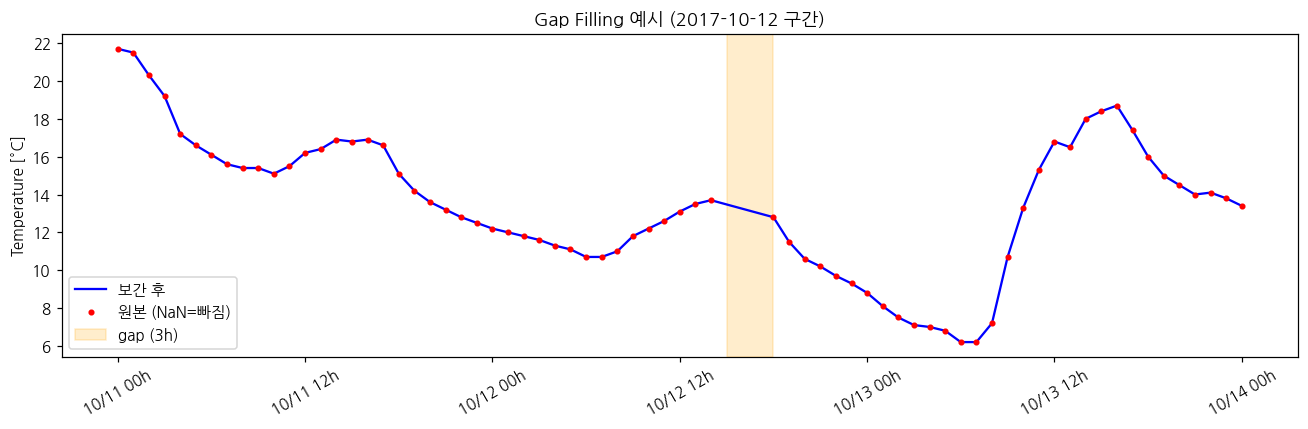

In [12]:
# gap 보간 시각화 (2017년 10월 gap 구간)
gap_start_vis = pd.Timestamp('2017-10-11')
gap_end_vis   = pd.Timestamp('2017-10-14')

fig, ax = plt.subplots(figsize=(12, 4))

orig = df_indexed.loc[gap_start_vis:gap_end_vis, 'TA']
filled = df_fill.loc[gap_start_vis:gap_end_vis, 'TA']

ax.plot(filled.index, filled.values, 'b-', lw=1.5, label='보간 후')
ax.plot(orig.index, orig.values, 'ro', ms=3, label='원본 (NaN=빠짐)')

# gap 위치 표시
for _, row in gap_df[(gap_df['start'] >= gap_start_vis) & (gap_df['start'] <= gap_end_vis)].iterrows():
    ax.axvspan(row['start'], row['end'], alpha=0.2, color='orange', label=f"gap ({row['hours']}h)")

ax.legend()
ax.set_title('Gap Filling 예시 (2017-10-12 구간)', fontsize=12)
ax.set_ylabel('Temperature [°C]')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d %Hh'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 5. 강수(RN) 특수 처리: 0 vs 결측 구분

**ASOS 강수 코드 규칙**
- `-9.0` : 관측 없음 → **0mm (비 안 옴)** 으로 해석 (ASOS는 비가 오면 무조건 기록)
- `0.0` : 0.1mm 미만 미량 강수 혹은 확실한 0
- `>0` : 실제 강수

> 단, 센서 장애나 통신 장애 구간의 -9는 진짜 결측. IX(정보 품질 플래그)로 구분 가능

In [13]:
df_fill2 = df_fill.copy()

# IX 컬럼: 1=정상, 4=장애추정 등
# IX가 있으면 장애 구간의 -9는 NaN, 나머지 -9는 0으로
if 'IX' in df_fill2.columns:
    normal_obs = df_fill2['IX'].isin([1, 2, 3])  # 정상 관측
    rn_mask_zero = (df_fill2['RN'] == -9) & normal_obs
    rn_mask_nan  = (df_fill2['RN'] == -9) & ~normal_obs
    df_fill2.loc[rn_mask_zero, 'RN'] = 0.0
    df_fill2.loc[rn_mask_nan, 'RN'] = np.nan
    print(f'RN: -9→0 처리 {rn_mask_zero.sum():,}개, -9→NaN {rn_mask_nan.sum():,}개')
else:
    # IX 없으면 -9를 모두 0으로 (보수적 처리)
    n = (df_fill2['RN'] == -9).sum()
    df_fill2.loc[df_fill2['RN'] == -9, 'RN'] = 0.0
    print(f'RN: -9→0 처리 {n:,}개 (IX 컬럼 없어 전부 0 처리)')

# RN_DAY, RN_INT도 동일 처리
for col in ['RN_DAY','RN_INT']:
    if col in df_fill2.columns:
        n = (df_fill2[col] == -9).sum()
        df_fill2.loc[df_fill2[col] == -9, col] = 0.0
        print(f'{col}: -9→0 처리 {n:,}개')

print(f'\nRN 최종 분포:')
print(f'  0mm: {(df_fill2["RN"]==0).sum():,}개 ({(df_fill2["RN"]==0).mean()*100:.1f}%)')
print(f'  >0mm: {(df_fill2["RN"]>0).sum():,}개 ({(df_fill2["RN"]>0).mean()*100:.1f}%)')
print(f'  NaN: {df_fill2["RN"].isna().sum():,}개')

RN: -9→0 처리 76,719개, -9→NaN 2,215개
RN_DAY: -9→0 처리 63,458개
RN_INT: -9→0 처리 63,466개

RN 최종 분포:
  0mm: 80,565개 (91.9%)
  >0mm: 4,863개 (5.5%)
  NaN: 2,220개


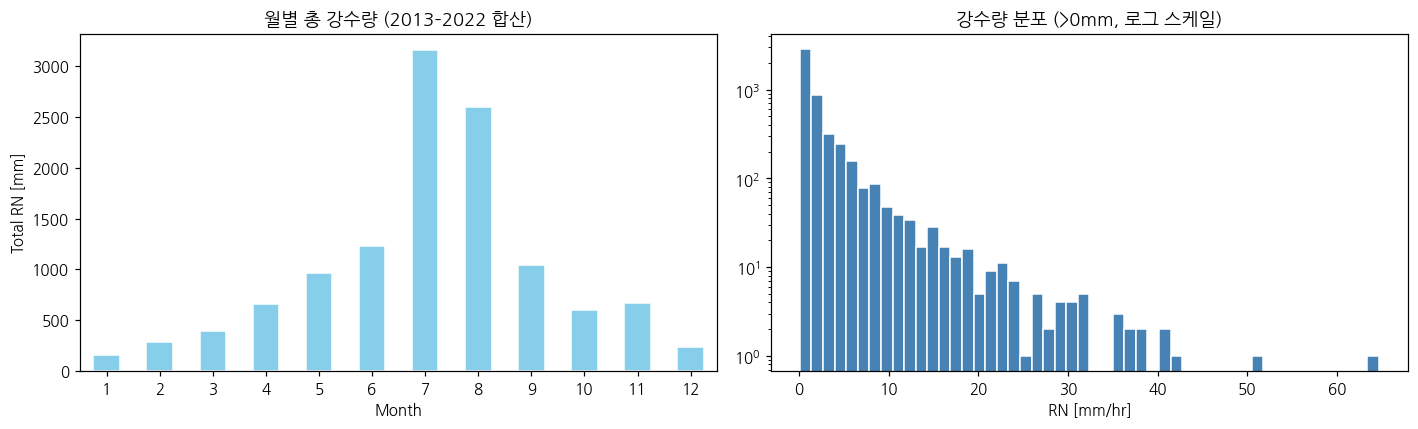

In [14]:
# 연간 강수 패턴 확인
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 월별 강수 합계
ax = axes[0]
monthly_rn = df_fill2.groupby(df_fill2.index.month)['RN'].sum()
monthly_rn.plot(kind='bar', ax=ax, color='skyblue', edgecolor='white')
ax.set_title('월별 총 강수량 (2013–2022 합산)', fontsize=12)
ax.set_xlabel('Month')
ax.set_ylabel('Total RN [mm]')
ax.set_xticklabels(range(1,13), rotation=0)

# 강수량 분포 (로그 스케일)
ax = axes[1]
rn_pos = df_fill2[df_fill2['RN'] > 0]['RN']
ax.hist(rn_pos, bins=50, color='steelblue', edgecolor='white')
ax.set_yscale('log')
ax.set_title('강수량 분포 (>0mm, 로그 스케일)', fontsize=12)
ax.set_xlabel('RN [mm/hr]')

plt.tight_layout()
plt.show()

## 6. 피처 선택 & 불필요 컬럼 제거

AI 모델에 투입할 컬럼 선별:
- `SD_HR3`, `SD_DAY`, `SD_TOT`: 서울(STN=108) 적설 관측 없음 → 전체 -9 → 제거
- `GST_WD/WS/TM`: 순간최대풍 관련 → 결측 많음
- `CT`, `CT_TOP` 등 문자형 구름 타입 컬럼 → 인코딩 필요 (별도)
- `STN`: 단일 관측소 → 상수 → 제거

=== 결측률 상위 컬럼 ===
  WH           (파고 [m]              ) : 100.0%
  SD_HR3       (3시간적설 [cm]          ) : 100.0%
  BF           (보퍼트 풍력계급            ) : 100.0%
  SD_DAY       (일적설 [cm]            ) : 99.7%
  SD_TOT       (적설 [cm]             ) : 98.8%
  GST_WS       (순간최대풍속 [m/s]        ) : 94.8%
  GST_WD       (순간최대풍향 [°]          ) : 94.8%
  ST_GD        (지면상태 코드             ) : 45.6%
  SI           (일사 [MJ/m²]          ) : 45.4%
  CA_MID       (중하층운량 [0-10]        ) : 12.3%
  CH_MIN       (최저운고 [100ft]        ) : 8.2%


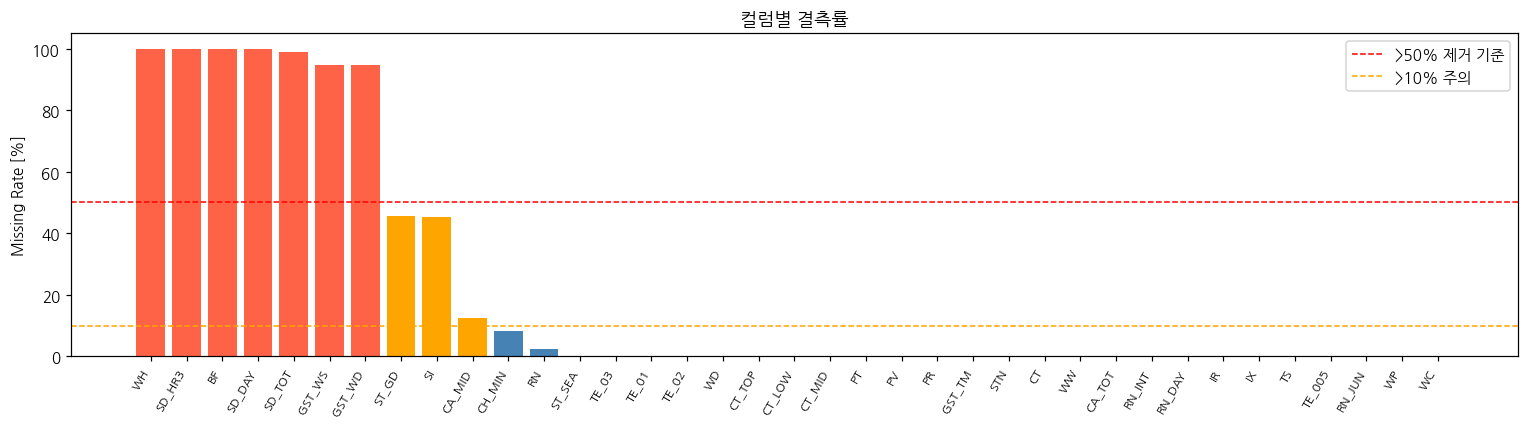

In [15]:
# 결측률 계산
nan_rate = df_fill2.isna().mean().sort_values(ascending=False)
print('=== 결측률 상위 컬럼 ===')
for col, rate in nan_rate[nan_rate > 0.05].items():
    print(f'  {col:12s} ({COL_DESC.get(col, "-"):20s}) : {rate*100:.1f}%')

# 전체 결측률 시각화
fig, ax = plt.subplots(figsize=(14, 4))
nan_rate_plot = nan_rate[nan_rate > 0]
colors = ['tomato' if v > 0.5 else 'orange' if v > 0.1 else 'steelblue' for v in nan_rate_plot]
ax.bar(range(len(nan_rate_plot)), nan_rate_plot.values * 100, color=colors)
ax.set_xticks(range(len(nan_rate_plot)))
ax.set_xticklabels(nan_rate_plot.index, rotation=60, ha='right', fontsize=8)
ax.axhline(50, color='red', ls='--', lw=1, label='>50% 제거 기준')
ax.axhline(10, color='orange', ls='--', lw=1, label='>10% 주의')
ax.set_title('컬럼별 결측률', fontsize=12)
ax.set_ylabel('Missing Rate [%]')
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# 제거 대상 컬럼
DROP_COLS = [
    'STN',                           # 상수
    'PT','PR',                       # 기압경향 (범주형)
    'WC','WP','WW',                  # 기상현상 코드 (범주형)
    'CT','CT_TOP','CT_MID','CT_LOW', # 구름 형태 (문자 범주형)
    'GST_TM',                        # 순간최대풍 시각 (문자형)
    'ST_SEA','WH',                   # 해면수온·파고 (내륙 관측소)
    'GAP_FLAG',                      # 임시 플래그
]

# 결측률 50% 초과 컬럼 자동 추가
nan_rate = df_fill2.isna().mean()
high_missing = nan_rate[nan_rate > 0.5].index.tolist()
auto_dropped = [c for c in high_missing if c not in DROP_COLS]
DROP_COLS += auto_dropped

print('=== 결측률 50% 초과 자동 제거 ===')
for col in auto_dropped:
    print(f'  {col:12s} ({COL_DESC.get(col, "-"):20s}) : {nan_rate[col]*100:.1f}%')

DROP_COLS = [c for c in DROP_COLS if c in df_fill2.columns]
df_clean = df_fill2.drop(columns=DROP_COLS).copy()

print(f'\n제거된 컬럼 ({len(DROP_COLS)}개)')
print(f'남은 컬럼  ({len(df_clean.columns)}개): {list(df_clean.columns)}')
print(f'DataFrame shape: {df_clean.shape}')
print(f'잔여 NaN: {df_clean.isna().sum().sum():,}개')

=== 결측률 50% 초과 자동 제거 ===
  GST_WD       (순간최대풍향 [°]          ) : 94.8%
  GST_WS       (순간최대풍속 [m/s]        ) : 94.8%
  SD_HR3       (3시간적설 [cm]          ) : 100.0%
  SD_DAY       (일적설 [cm]            ) : 99.7%
  SD_TOT       (적설 [cm]             ) : 98.8%
  BF           (보퍼트 풍력계급            ) : 100.0%

제거된 컬럼 (20개)
남은 컬럼  (26개): ['WD', 'WS', 'PA', 'PS', 'TA', 'TD', 'HM', 'PV', 'RN', 'RN_DAY', 'RN_INT', 'CA_TOT', 'CA_MID', 'CH_MIN', 'VS', 'SS', 'SI', 'ST_GD', 'TS', 'TE_005', 'TE_01', 'TE_02', 'TE_03', 'IR', 'IX', 'RN_JUN']
DataFrame shape: (87648, 26)
잔여 NaN: 100,206개


## 7. 표준화 (Standardization) / 정규화 (Normalization)

| 방법 | 공식 | 적합 케이스 |
|------|------|------------|
| **Z-score** | `(x - μ) / σ` | 기온·습도·기압 등 정규분포에 가까운 변수 |
| **Min-Max** | `(x - min) / (max - min)` | 0-1 범위가 의미있는 변수 (HM, SS 등) |
| **Log 변환 + Z** | `log1p(x)` → Z-score | 강수·적설 등 right-skewed 변수 |

> **중요**: 스케일러는 학습 데이터(train)로만 fit하고 검증/테스트에 transform만 적용!

In [17]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import joblib

# 학습/검증/테스트 분할 (시간순 분할 — 미래 누설 방지)
# 2013–2020: train (80%), 2021: val (10%), 2022: test (10%)
train_mask = df_clean.index.year <= 2020
val_mask   = df_clean.index.year == 2021
test_mask  = df_clean.index.year == 2022

print(f'Train: {train_mask.sum():,} rows ({df_clean.index[train_mask].min().date()} ~ {df_clean.index[train_mask].max().date()})')
print(f'Val:   {val_mask.sum():,} rows ({df_clean.index[val_mask].min().date()} ~ {df_clean.index[val_mask].max().date()})')
print(f'Test:  {test_mask.sum():,} rows ({df_clean.index[test_mask].min().date()} ~ {df_clean.index[test_mask].max().date()})')

Train: 70,128 rows (2013-01-01 ~ 2020-12-31)
Val:   8,760 rows (2021-01-01 ~ 2021-12-31)
Test:  8,760 rows (2022-01-01 ~ 2022-12-31)


In [18]:
# 잔여 NaN 처리 전략: ffill → bfill → train 평균 순서로 적용
# (데이터 누설 방지: train 평균은 train 구간에서만 계산)
num_cols = df_clean.select_dtypes(include='number').columns.tolist()
nan_cols = [c for c in num_cols if df_clean[c].isna().any()]

print('=== 잔여 NaN 처리 (ffill → bfill → train 평균) ===')
train_means = {}
drop_all_nan = []

for col in nan_cols:
    n_before = df_clean[col].isna().sum()

    # 1단계: ffill → bfill
    df_clean[col] = df_clean[col].ffill().bfill()
    n_after_fb = df_clean[col].isna().sum()

    # 2단계: 아직 NaN이 남아있으면 train 평균으로 채우기
    mean_val = df_clean.loc[train_mask, col].mean()
    if pd.isna(mean_val):
        drop_all_nan.append(col)
        print(f'  {col:12s} ({COL_DESC.get(col,"-"):20s}) : train 전체 NaN → 컬럼 제거')
        continue

    n_mean_filled = df_clean[col].isna().sum()
    if n_mean_filled > 0:
        df_clean[col] = df_clean[col].fillna(mean_val)

    train_means[col] = mean_val
    print(f'  {col:12s} ({COL_DESC.get(col,"-"):20s}) : '
          f'총 {n_before:,}개 → ffill/bfill {n_before - n_after_fb:,}개 '
          f'+ 평균 {n_mean_filled:,}개 채움')

# train 전체 NaN 컬럼 제거
if drop_all_nan:
    df_clean.drop(columns=drop_all_nan, inplace=True)
    num_cols = [c for c in num_cols if c not in drop_all_nan]
    print(f'\n제거된 컬럼 ({len(drop_all_nan)}개): {drop_all_nan}')

# ── 최종 안전망: 숫자 컬럼 중 남은 NaN을 전체 평균으로 강제 처리 ──
still_nan_cols = [c for c in num_cols if df_clean[c].isna().any()]
if still_nan_cols:
    print(f'\n[안전망] 아직 NaN 잔여 컬럼: {still_nan_cols}')
    for col in still_nan_cols:
        global_mean = df_clean[col].mean()
        fill_val = global_mean if not pd.isna(global_mean) else 0.0
        df_clean[col] = df_clean[col].fillna(fill_val)
        print(f'  {col}: 전체평균 {fill_val:.3f}으로 강제 채움')

remaining = df_clean[num_cols].isna().sum().sum()
print(f'\n처리 후 잔여 NaN: {remaining}개 {"✓" if remaining == 0 else "← 확인 필요"}')

# train 평균값 저장
import json
with open(os.path.join(OUTPUT_DIR, 'train_fill_means.json'), 'w') as f:
    json.dump({k: float(v) for k, v in train_means.items()}, f, indent=2)
print('train_fill_means.json 저장 완료')

=== 잔여 NaN 처리 (ffill → bfill → train 평균) ===
  WD           (풍향 [°]              ) : 총 55개 → ffill/bfill 55개 + 평균 0개 채움
  PV           (수증기압 [hPa]          ) : 총 5개 → ffill/bfill 5개 + 평균 0개 채움
  RN           (강수량 [mm/hr]         ) : 총 2,220개 → ffill/bfill 2,220개 + 평균 0개 채움
  RN_DAY       (일강수량 [mm]           ) : 총 5개 → ffill/bfill 5개 + 평균 0개 채움
  RN_INT       (강수강도 [mm/hr]        ) : 총 5개 → ffill/bfill 5개 + 평균 0개 채움
  CA_MID       (중하층운량 [0-10]        ) : 총 10,810개 → ffill/bfill 10,810개 + 평균 0개 채움
  CH_MIN       (최저운고 [100ft]        ) : 총 7,146개 → ffill/bfill 7,146개 + 평균 0개 채움
  SI           (일사 [MJ/m²]          ) : 총 39,760개 → ffill/bfill 39,760개 + 평균 0개 채움
  ST_GD        (지면상태 코드             ) : 총 39,949개 → ffill/bfill 39,949개 + 평균 0개 채움
  TS           (지면온도 [°C]           ) : 총 5개 → ffill/bfill 5개 + 평균 0개 채움
  TE_005       (지중온도 5cm [°C]       ) : 총 5개 → ffill/bfill 5개 + 평균 0개 채움
  TE_01        (지중온도 10cm [°C]      ) : 총 72개 → ffill/bfill 72개 + 평균 0개 채움
  TE_02        (지중온도 20cm [°C

In [19]:
# 변수 그룹별 스케일러 지정
ZSCORE_COLS  = ['TA','TD','HM','WS','PA','PS','PV','VS','TE_005','TE_01','TE_02','TE_03']
MINMAX_COLS  = ['SS', 'SI']          # 0-1 자연 범위
LOG_COLS     = ['RN', 'RN_DAY']      # 강수: log1p 후 Z-score

# 실제로 존재하는 컬럼만
ZSCORE_COLS = [c for c in ZSCORE_COLS if c in df_clean.columns]
MINMAX_COLS = [c for c in MINMAX_COLS if c in df_clean.columns]
LOG_COLS    = [c for c in LOG_COLS    if c in df_clean.columns]

df_scaled = df_clean.copy()

# --- Z-score ---
scaler_z = StandardScaler()
df_scaled.loc[train_mask, ZSCORE_COLS] = scaler_z.fit_transform(
    df_clean.loc[train_mask, ZSCORE_COLS]
)
df_scaled.loc[~train_mask, ZSCORE_COLS] = scaler_z.transform(
    df_clean.loc[~train_mask, ZSCORE_COLS]
)

# --- Min-Max ---
if MINMAX_COLS:
    scaler_mm = MinMaxScaler()
    df_scaled.loc[train_mask, MINMAX_COLS] = scaler_mm.fit_transform(
        df_clean.loc[train_mask, MINMAX_COLS]
    )
    df_scaled.loc[~train_mask, MINMAX_COLS] = scaler_mm.transform(
        df_clean.loc[~train_mask, MINMAX_COLS]
    )

# --- Log + Z-score ---
if LOG_COLS:
    scaler_log = StandardScaler()
    log_train = np.log1p(df_clean.loc[train_mask, LOG_COLS].fillna(0))
    df_scaled.loc[train_mask, LOG_COLS] = scaler_log.fit_transform(log_train)
    log_rest = np.log1p(df_clean.loc[~train_mask, LOG_COLS].fillna(0))
    df_scaled.loc[~train_mask, LOG_COLS] = scaler_log.transform(log_rest)

# 스케일러 저장 (나중에 역변환용)
joblib.dump(scaler_z,  os.path.join(OUTPUT_DIR, 'scaler_zscore.pkl'))
joblib.dump(scaler_mm, os.path.join(OUTPUT_DIR, 'scaler_minmax.pkl')) if MINMAX_COLS else None
joblib.dump(scaler_log, os.path.join(OUTPUT_DIR, 'scaler_log.pkl')) if LOG_COLS else None

print('스케일링 완료')
print('\n스케일링 후 주요 컬럼 통계:')
df_scaled[ZSCORE_COLS[:5]].describe().round(3)

스케일링 완료

스케일링 후 주요 컬럼 통계:


,TA,TD,HM,WS,PA
count,87648.000,87648.000,87648.000,87648.000,87648.000
mean,0.005,0.028,0.054,0.001,-0.002
std,1.001,0.999,0.990,0.974,0.999
min,-2.875,-2.918,-2.621,-1.775,-3.800
25%,-0.811,-0.754,-0.679,-0.709,-0.788
50%,0.094,0.092,0.067,-0.100,0.023
75%,0.864,0.906,0.864,0.585,0.773
max,2.366,1.882,2.009,6.296,2.727


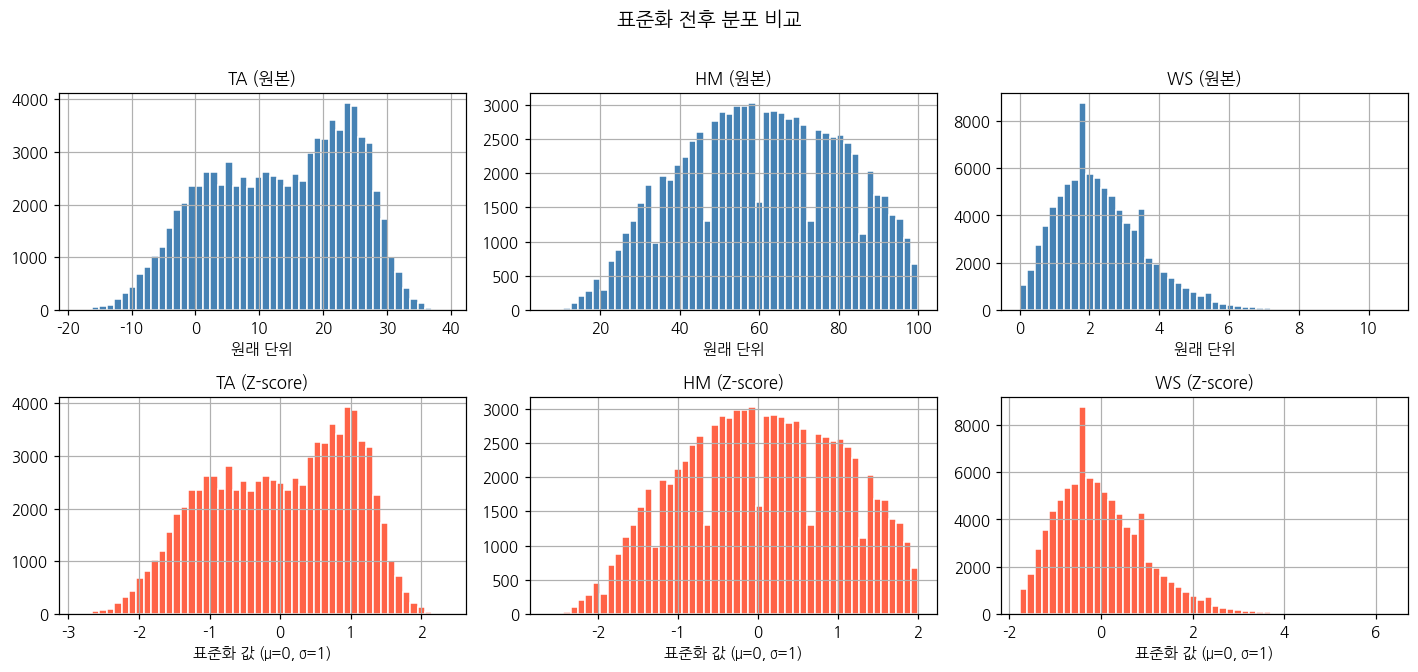

In [20]:
# 스케일링 전후 분포 비교
compare_cols = ['TA','HM','WS']
compare_cols = [c for c in compare_cols if c in df_clean.columns]

fig, axes = plt.subplots(2, len(compare_cols), figsize=(13, 6))

for i, col in enumerate(compare_cols):
    # 원본
    ax = axes[0, i]
    df_clean[col].dropna().hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{col} (원본)', fontsize=11)
    ax.set_xlabel('원래 단위')
    
    # 스케일링 후
    ax = axes[1, i]
    df_scaled[col].dropna().hist(bins=50, ax=ax, color='tomato', edgecolor='white')
    ax.set_title(f'{col} (Z-score)', fontsize=11)
    ax.set_xlabel('표준화 값 (μ=0, σ=1)')

plt.suptitle('표준화 전후 분포 비교', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 8. AI-Ready 저장 및 최종 검증

In [21]:
# 분할 저장
df_train = df_scaled[train_mask]
df_val   = df_scaled[val_mask]
df_test  = df_scaled[test_mask]

df_train.to_csv(os.path.join(OUTPUT_DIR, 'train.csv'))
df_val.to_csv(os.path.join(OUTPUT_DIR,   'val.csv'))
df_test.to_csv(os.path.join(OUTPUT_DIR,  'test.csv'))

# 원본 스케일(clean) 전체도 저장
df_clean.to_csv(os.path.join(OUTPUT_DIR, 'asos_2013_2022_clean.csv'))

print('저장 완료:')
print(f'  train.csv : {len(df_train):,} rows')
print(f'  val.csv   : {len(df_val):,} rows')
print(f'  test.csv  : {len(df_test):,} rows')
print(f'  asos_2013_2022_clean.csv : {len(df_clean):,} rows')

저장 완료:
  train.csv : 70,128 rows
  val.csv   : 8,760 rows
  test.csv  : 8,760 rows
  asos_2013_2022_clean.csv : 87,648 rows


In [24]:
# 최종 품질 검증
print("="*55)
print("AI-Ready 데이터 최종 품질 리포트")
print("="*55)

for name, d in [("train", df_train), ("val", df_val), ("test", df_test)]:
    num_cols = d.select_dtypes(include="number").columns
    nan_total = d[num_cols].isna().sum().sum()
    nan_rate_total = nan_total / (len(d) * len(num_cols)) * 100
    dt = d.index.to_series().diff().dropna()
    time_gaps = (dt != pd.Timedelta("1h")).sum()

    print(f"\n[{name}]")
    print(f"  rows: {len(d):,} | cols: {len(num_cols)}")
    print(f"  전체 NaN: {nan_total:,} ({nan_rate_total:.3f}%)")
    print(f"  시간 불연속: {time_gaps}개")

    nan_by_col = d[num_cols].isna().sum()
    nan_by_col = nan_by_col[nan_by_col > 0].sort_values(ascending=False)
    if len(nan_by_col) > 0:
        print(f"  ── NaN 잔여 컬럼 ({len(nan_by_col)}개) ──")
        for col, cnt in nan_by_col.items():
            print(f"    {col:12s} ({COL_DESC.get(col, chr(45)):20s}): {cnt:,}개 ({cnt/len(d)*100:.2f}%)")
    else:
        print("  NaN 없음 ✓")

print("\n" + "="*55)
print("최종 포함 변수 목록")
print("="*55)
final_cols = df_train.select_dtypes(include="number").columns.tolist()
for i, col in enumerate(final_cols, 1):
    print(f"  {i:2d}. {col:12s} : {COL_DESC.get(col, chr(45))}")
print(f"\n총 {len(final_cols)}개 변수")
print("="*55)

AI-Ready 데이터 최종 품질 리포트

[train]
  rows: 70,128 | cols: 25
  전체 NaN: 0 (0.000%)
  시간 불연속: 0개
  NaN 없음 ✓

[val]
  rows: 8,760 | cols: 25
  전체 NaN: 0 (0.000%)
  시간 불연속: 0개
  NaN 없음 ✓

[test]
  rows: 8,760 | cols: 25
  전체 NaN: 0 (0.000%)
  시간 불연속: 0개
  NaN 없음 ✓

최종 포함 변수 목록
   1. WD           : 풍향 [°]
   2. WS           : 풍속 [m/s]
   3. PA           : 현지기압 [hPa]
   4. PS           : 해면기압 [hPa]
   5. TA           : 기온 [°C]
   6. TD           : 이슬점온도 [°C]
   7. HM           : 상대습도 [%]
   8. PV           : 수증기압 [hPa]
   9. RN           : 강수량 [mm/hr]
  10. RN_DAY       : 일강수량 [mm]
  11. RN_INT       : 강수강도 [mm/hr]
  12. CA_MID       : 중하층운량 [0-10]
  13. CH_MIN       : 최저운고 [100ft]
  14. VS           : 시정 [m]
  15. SS           : 일조 [초, 0-3600]
  16. SI           : 일사 [MJ/m²]
  17. ST_GD        : 지면상태 코드
  18. TS           : 지면온도 [°C]
  19. TE_005       : 지중온도 5cm [°C]
  20. TE_01        : 지중온도 10cm [°C]
  21. TE_02        : 지중온도 20cm [°C]
  22. TE_03        : 지중온도 30cm [°C]
  23. IR           

In [25]:
# 전처리 파이프라인 요약
summary = """
=== ASOS 전처리 파이프라인 요약 ===

1. Sentinel 처리 (-9 → NaN)
   - RN 제외 모든 수치 컬럼 처리
   - -99 (TA 3개) 추가 처리

2. 이상값 제거 (물리적 범위 기반)
   - 방법: 도메인 지식 기반 상·하한 설정
   - IQR보다 기상 데이터에 적합

3. Gap Filling (시간 연속성)
   - ≤6h: 선형 보간
   - 6~24h: 월·시각 기후 평균 보간
   - >24h: GAP_FLAG 표시

4. 강수(RN) 특수 처리
   - -9 → 0mm (IX 기반 품질 플래그 활용)
   - log1p 변환 + Z-score

5. 피처 선택
   - 상수, 전체결측, 문자형 범주 컬럼 제거

6. 표준화
   - Z-score: TA, TD, HM, WS, PA, PS, ...
   - Min-Max: SS, SI
   - Log+Z: RN, RN_DAY
   - 스케일러: train-fit, val/test-transform only

7. 분할: train(2013-2020) / val(2021) / test(2022)
"""
print(summary)


=== ASOS 전처리 파이프라인 요약 ===

1. Sentinel 처리 (-9 → NaN)
   - RN 제외 모든 수치 컬럼 처리
   - -99 (TA 3개) 추가 처리

2. 이상값 제거 (물리적 범위 기반)
   - 방법: 도메인 지식 기반 상·하한 설정
   - IQR보다 기상 데이터에 적합

3. Gap Filling (시간 연속성)
   - ≤6h: 선형 보간
   - 6~24h: 월·시각 기후 평균 보간
   - >24h: GAP_FLAG 표시

4. 강수(RN) 특수 처리
   - -9 → 0mm (IX 기반 품질 플래그 활용)
   - log1p 변환 + Z-score

5. 피처 선택
   - 상수, 전체결측, 문자형 범주 컬럼 제거

6. 표준화
   - Z-score: TA, TD, HM, WS, PA, PS, ...
   - Min-Max: SS, SI
   - Log+Z: RN, RN_DAY
   - 스케일러: train-fit, val/test-transform only

7. 분할: train(2013-2020) / val(2021) / test(2022)

